# **Network Analysis**

# Import Libraries

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

# Network Loading

In [2]:
# Bipartite network
df_bipartite = pd.read_csv('../data/processed/bipartite-network-edges.csv')
G_bipartite = nx.from_pandas_edgelist(df_bipartite, source='source', target='target')

# pos = nx.spring_layout(G_bipartite)
# nx.draw(G_bipartite, pos, with_labels=True, node_color='skyblue', node_size=1500, font_size=12)
# nx.draw_networkx_edge_labels(G_bipartite, pos)
# plt.show()

# Degree Distribution

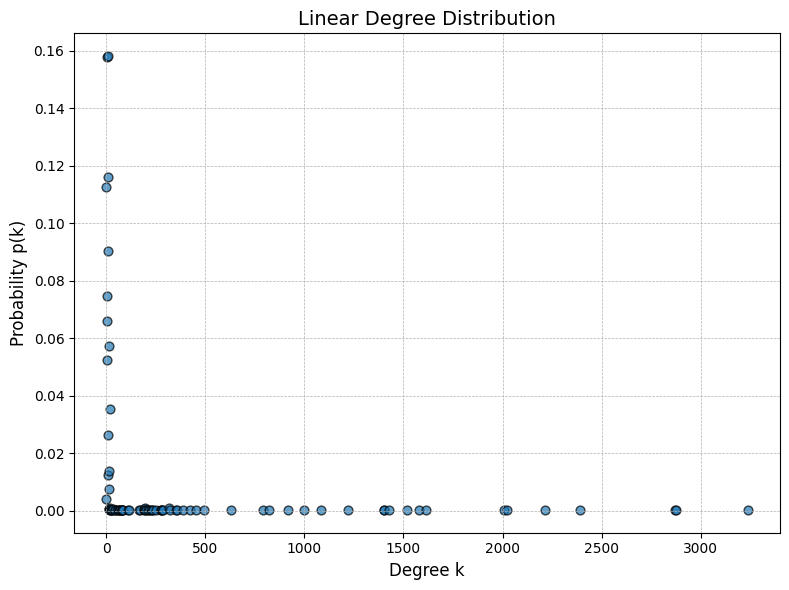

In [3]:
# Compute degree sequence
degree_sequence = np.array([d for _, d in G_bipartite.degree()])

# Compute degree frequencies
degree_values, degree_counts = np.unique(degree_sequence, return_counts=True)

# Normalize to get probabilities
degree_prob = degree_counts / degree_counts.sum()

# Scatter plot visualization
plt.figure(figsize=(8, 6))
plt.scatter(degree_values, degree_prob, s=40, alpha=0.7, edgecolor='black')

plt.title('Linear Degree Distribution', fontsize=14)
plt.xlabel('Degree k', fontsize=12)
plt.ylabel('Probability p(k)', fontsize=12)
plt.grid(True, ls='--', lw=0.5)
plt.tight_layout()
plt.show()

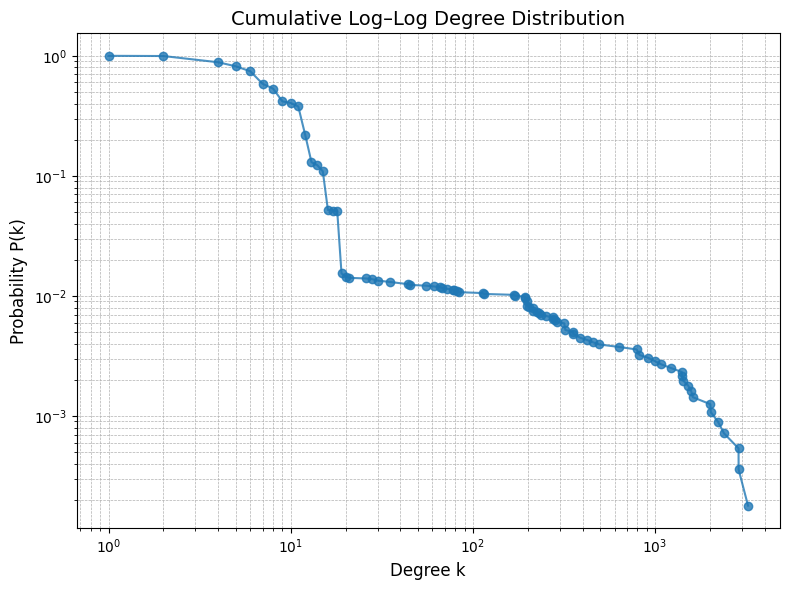

In [4]:
# Compute degree sequence
degree_sequence = np.array([d for _, d in G_bipartite.degree()])

# Compute histogram and cumulative
degree_values, degree_counts = np.unique(degree_sequence, return_counts=True)
cdf = np.cumsum(degree_counts[::-1])[::-1]  # Reverse cumulative sum
ccdf = cdf / cdf[0]  # Normalize to get probability P(k' ≥ k)

# Plot on log–log scale
plt.figure(figsize=(8, 6))
plt.loglog(degree_values, ccdf, marker='o', linestyle='-', alpha=0.8)

plt.title('Cumulative Log–Log Degree Distribution', fontsize=14)
plt.xlabel('Degree k', fontsize=12)
plt.ylabel('Probability P(k)', fontsize=12)
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()

# Metric Calculation